# 🌦️ Kenya Local Weather Forecasting — Deep Learning Pipeline
**Meru University**

This notebook covers:
1. Data Collection
2. Data loading & exploration
3. Preprocessing & feature engineering
4. LSTM model
5. GRU model
6. ConvLSTM model
7. Model comparison (MAE, RMSE, MAPE, R²)
8. Save best model for deployment

**Predicts:** Temperature, Rainfall, Humidity, Wind Speed, Pressure  
**Horizon:** 7 days ahead  
**Coverage:** All 47 Kenya Counties

## 📂 Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install requests pandas tqdm
!python collect_kenya_weather.py

python3: can't open file '/content/collect_kenya_weather.py': [Errno 2] No such file or directory


In [ ]:
"""
Kenya County Weather Data Collector
=======================================
"""

import requests
import pandas as pd
import time
import os
from tqdm import tqdm

# ── Google Drive output (change if needed) ───────────────────────────────────
OUTPUT_DIR = "/content/drive/MyDrive/kenya_weather_data"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── All 47 Kenya Counties ────────────────────────────────────────────────────
KENYA_COUNTIES = [
    {"county": "Nairobi",         "lat": -1.2921,  "lon": 36.8219},
    {"county": "Mombasa",         "lat": -4.0435,  "lon": 39.6682},
    {"county": "Kwale",           "lat": -4.1817,  "lon": 39.4606},
    {"county": "Kilifi",          "lat": -3.5107,  "lon": 39.9093},
    {"county": "Tana River",      "lat": -1.0166,  "lon": 39.9093},
    {"county": "Lamu",            "lat": -2.2686,  "lon": 40.9020},
    {"county": "Taita Taveta",    "lat": -3.3160,  "lon": 38.4806},
    {"county": "Garissa",         "lat": -0.4532,  "lon": 39.6461},
    {"county": "Wajir",           "lat":  1.7471,  "lon": 40.0573},
    {"county": "Mandera",         "lat":  3.9366,  "lon": 41.8670},
    {"county": "Marsabit",        "lat":  2.3284,  "lon": 37.9899},
    {"county": "Isiolo",          "lat":  0.3556,  "lon": 37.5822},
    {"county": "Meru",            "lat":  0.0467,  "lon": 37.6491},
    {"county": "Tharaka Nithi",   "lat": -0.2960,  "lon": 37.9187},
    {"county": "Embu",            "lat": -0.5300,  "lon": 37.4500},
    {"county": "Kitui",           "lat": -1.3667,  "lon": 38.0107},
    {"county": "Machakos",        "lat": -1.5177,  "lon": 37.2634},
    {"county": "Makueni",         "lat": -2.2588,  "lon": 37.8942},
    {"county": "Nyandarua",       "lat": -0.1807,  "lon": 36.5219},
    {"county": "Nyeri",           "lat": -0.4167,  "lon": 36.9500},
    {"county": "Kirinyaga",       "lat": -0.5593,  "lon": 37.2490},
    {"county": "Murang'a",        "lat": -0.7167,  "lon": 37.1500},
    {"county": "Kiambu",          "lat": -1.0315,  "lon": 36.8318},
    {"county": "Turkana",         "lat":  3.1220,  "lon": 35.5980},
    {"county": "West Pokot",      "lat":  1.6200,  "lon": 35.3900},
    {"county": "Samburu",         "lat":  1.2167,  "lon": 36.9500},
    {"county": "Trans Nzoia",     "lat":  1.0167,  "lon": 34.9500},
    {"county": "Uasin Gishu",     "lat":  0.5143,  "lon": 35.2698},
    {"county": "Elgeyo Marakwet", "lat":  0.7833,  "lon": 35.5167},
    {"county": "Nandi",           "lat":  0.1833,  "lon": 35.1167},
    {"county": "Baringo",         "lat":  0.4667,  "lon": 36.0667},
    {"county": "Laikipia",        "lat":  0.3606,  "lon": 36.7819},
    {"county": "Nakuru",          "lat": -0.3031,  "lon": 36.0800},
    {"county": "Narok",           "lat": -1.0833,  "lon": 35.8667},
    {"county": "Kajiado",         "lat": -1.8500,  "lon": 36.7833},
    {"county": "Kericho",         "lat": -0.3667,  "lon": 35.2833},
    {"county": "Bomet",           "lat": -0.7833,  "lon": 35.3500},
    {"county": "Kakamega",        "lat":  0.2833,  "lon": 34.7500},
    {"county": "Vihiga",          "lat":  0.0667,  "lon": 34.7167},
    {"county": "Bungoma",         "lat":  0.5635,  "lon": 34.5606},
    {"county": "Busia",           "lat":  0.4608,  "lon": 34.1118},
    {"county": "Siaya",           "lat": -0.0617,  "lon": 34.2879},
    {"county": "Kisumu",          "lat": -0.0917,  "lon": 34.7679},
    {"county": "Homa Bay",        "lat": -0.5167,  "lon": 34.4500},
    {"county": "Migori",          "lat": -1.0634,  "lon": 34.4731},
    {"county": "Kisii",           "lat": -0.6817,  "lon": 34.7667},
    {"county": "Nyamira",         "lat": -0.5667,  "lon": 34.9333},
]

START_DATE = "2015-01-01"
END_DATE   = "2024-12-31"

# ── Robust API fetch with retry + exponential backoff ────────────────────────
def fetch_with_retry(url, params, max_retries=5):
    """Fetch URL with automatic retry on 429 / network errors."""
    for attempt in range(max_retries):
        try:
            resp = requests.get(url, params=params, timeout=60)

            if resp.status_code == 429:
                wait = 30 * (attempt + 1)   # 30s, 60s, 90s, 120s, 150s
                print(f"\n  ⏳ Rate limited. Waiting {wait}s before retry {attempt+1}/{max_retries}...")
                time.sleep(wait)
                continue

            resp.raise_for_status()
            return resp.json()

        except requests.exceptions.ConnectionError:
            wait = 15 * (attempt + 1)
            print(f"\n  🔌 Connection error. Waiting {wait}s...")
            time.sleep(wait)

        except requests.exceptions.Timeout:
            print(f"\n  ⏱ Timeout. Retrying {attempt+1}/{max_retries}...")
            time.sleep(10)

    raise Exception(f"Failed after {max_retries} retries")


def fetch_county_data(county_info):
    """Fetch all weather variables for one county in a single API call."""
    params = {
        "latitude":   county_info["lat"],
        "longitude":  county_info["lon"],
        "start_date": START_DATE,
        "end_date":   END_DATE,
        "daily": ",".join([
            "temperature_2m_max",
            "temperature_2m_min",
            "temperature_2m_mean",
            "precipitation_sum",
            "windspeed_10m_max",
            "shortwave_radiation_sum",
            "et0_fao_evapotranspiration",  # bonus: useful for agriculture
        ]),
        "hourly": "relativehumidity_2m,surface_pressure",
        "timezone": "Africa/Nairobi",
    }

    url  = "https://archive-api.open-meteo.com/v1/archive"
    data = fetch_with_retry(url, params)

    # ── Daily variables ───────────────────────────────────────────────────────
    daily_df = pd.DataFrame(data["daily"])
    daily_df.rename(columns={"time": "date"}, inplace=True)
    daily_df["date"] = pd.to_datetime(daily_df["date"])

    # ── Hourly → daily mean ───────────────────────────────────────────────────
    hourly_df = pd.DataFrame(data["hourly"])
    hourly_df["time"] = pd.to_datetime(hourly_df["time"])
    hourly_df["date"] = hourly_df["time"].dt.normalize()
    daily_humidity = hourly_df.groupby("date")[["relativehumidity_2m", "surface_pressure"]].mean().reset_index()

    # ── Merge ─────────────────────────────────────────────────────────────────
    df = pd.merge(daily_df, daily_humidity, on="date", how="left")

    # ── Rename columns to clean names ─────────────────────────────────────────
    df.rename(columns={
        "temperature_2m_max":           "temp_max_c",
        "temperature_2m_min":           "temp_min_c",
        "temperature_2m_mean":          "temp_mean_c",
        "precipitation_sum":            "rainfall_mm",
        "windspeed_10m_max":            "windspeed_kmh",
        "shortwave_radiation_sum":      "solar_radiation_mjm2",
        "et0_fao_evapotranspiration":   "evapotranspiration_mm",
        "relativehumidity_2m":          "humidity_pct",
        "surface_pressure":             "pressure_hpa",
    }, inplace=True)

    # ── Add metadata columns ──────────────────────────────────────────────────
    df.insert(0, "county",    county_info["county"])
    df.insert(1, "latitude",  county_info["lat"])
    df.insert(2, "longitude", county_info["lon"])

    return df


# ── Main ─────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    print("=" * 60)
    print("  Kenya County Weather Data Collector v2")
    print(f"  Period  : {START_DATE} → {END_DATE}")
    print(f"  Counties: {len(KENYA_COUNTIES)}")
    print(f"  Output  : {OUTPUT_DIR}")
    print("  NOTE    : ~3 seconds between requests to avoid 429s")
    print("=" * 60)

    # Check which counties already downloaded (resume support)
    already_done = set()
    for f in os.listdir(OUTPUT_DIR):
        if f.endswith(".csv") and f != "kenya_all_counties.csv":
            already_done.add(f.replace(".csv", "").replace("_", " "))

    if already_done:
        print(f"\n  Resuming — {len(already_done)} counties already downloaded, skipping them.")

    successful = []
    failed     = []

    for county in tqdm(KENYA_COUNTIES, desc="Downloading", unit="county"):
        name = county["county"]

        # Skip already downloaded
        if name.replace(" ", "_") in [a.replace(" ", "_") for a in already_done]:
            successful.append(name)
            continue

        try:
            df = fetch_county_data(county)

            # Save individual county CSV
            safe_name = name.replace(" ", "_").replace("'", "")
            out_path  = os.path.join(OUTPUT_DIR, f"{safe_name}.csv")
            df.to_csv(out_path, index=False)
            successful.append(name)

            # Wait between requests — KEY FIX for 429 errors
            time.sleep(3)

        except Exception as e:
            failed.append({"county": name, "error": str(e)})
            print(f"\n  ✗ {name}: {e}")
            time.sleep(5)  # extra pause after failure

    # ── Combine all into master CSV ───────────────────────────────────────────
    print("\n  Combining all county files into master CSV...")
    all_dfs = []
    for f in os.listdir(OUTPUT_DIR):
        if f.endswith(".csv") and f != "kenya_all_counties.csv":
            all_dfs.append(pd.read_csv(os.path.join(OUTPUT_DIR, f)))

    if all_dfs:
        master = pd.concat(all_dfs, ignore_index=True)
        master = master.sort_values(["county", "date"]).reset_index(drop=True)
        master_path = os.path.join(OUTPUT_DIR, "kenya_all_counties.csv")
        master.to_csv(master_path, index=False)

    # ── Summary ───────────────────────────────────────────────────────────────
    print("\n" + "=" * 60)
    print(f"  ✓ Successful : {len(successful)}/{len(KENYA_COUNTIES)} counties")
    print(f"  ✗ Failed     : {len(failed)}")
    if all_dfs:
        print(f"  Master file  : kenya_all_counties.csv  ({len(master):,} rows)")
    print("=" * 60)

    if failed:
        print("\nFailed counties (re-run script to retry — it will skip successful ones):")
        for f in failed:
            print(f"  - {f['county']}: {f['error']}")

    print("\n✅ Done! Columns in your data:")
    print("   date, county, latitude, longitude,")
    print("   temp_max_c, temp_min_c, temp_mean_c,")
    print("   rainfall_mm, windspeed_kmh, solar_radiation_mjm2,")
    print("   evapotranspiration_mm, humidity_pct, pressure_hpa")
    print(f"\n📁 Files saved to: {OUTPUT_DIR}")

  Kenya County Weather Data Collector v2
  Period  : 2015-01-01 → 2024-12-31
  Counties: 47
  Output  : /content/drive/MyDrive/kenya_weather_data
  NOTE    : ~3 seconds between requests to avoid 429s

  Resuming — 38 counties already downloaded, skipping them.


Downloading:  47%|████▋     | 22/47 [00:19<00:31,  1.25s/county]


  ⏳ Rate limited. Waiting 30s before retry 1/5...

  ⏳ Rate limited. Waiting 60s before retry 2/5...


Downloading:  96%|█████████▌| 45/47 [02:14<00:06,  3.36s/county]


  ⏳ Rate limited. Waiting 30s before retry 1/5...

  ⏳ Rate limited. Waiting 60s before retry 2/5...


Downloading: 100%|██████████| 47/47 [03:58<00:00,  5.08s/county]



  Combining all county files into master CSV...

  ✓ Successful : 47/47 counties
  ✗ Failed     : 0
  Master file  : kenya_all_counties.csv  (171,691 rows)

✅ Done! Columns in your data:
   date, county, latitude, longitude,
   temp_max_c, temp_min_c, temp_mean_c,
   rainfall_mm, windspeed_kmh, solar_radiation_mjm2,
   evapotranspiration_mm, humidity_pct, pressure_hpa

📁 Files saved to: /content/drive/MyDrive/kenya_weather_data


## ⚙️Install & Import Libraries

In [ ]:
!pip install tensorflow scikit-learn pandas numpy matplotlib seaborn joblib -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, joblib
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import (
    Input, LSTM, GRU, Dense, Dropout, BatchNormalization,
    ConvLSTM2D, Reshape, Flatten, TimeDistributed
)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# Fix random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print('✅ Libraries loaded')
print(f'   TensorFlow version : {tf.__version__}')
print(f'   GPU available      : {len(tf.config.list_physical_devices("GPU")) > 0}')

✅ Libraries loaded
   TensorFlow version : 2.19.0
   GPU available      : True


## 📂  Mount Google Drive & Load Data

In [ ]:


DATA_PATH   = '/content/drive/MyDrive/kenya_weather_data/kenya_all_counties.csv'
OUTPUT_DIR  = '/content/drive/MyDrive/kenya_models'
os.makedirs(OUTPUT_DIR, exist_ok=True)

df = pd.read_csv(DATA_PATH, parse_dates=['date'])
df = df.sort_values(['county', 'date']).reset_index(drop=True)

print(f'✅ Data loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'   Counties : {df["county"].nunique()}')
print(f'   Date range: {df["date"].min().date()} → {df["date"].max().date()}')
print(f'\nColumns: {list(df.columns)}')
df.head(3)

✅ Data loaded: 171,691 rows × 13 columns
   Counties : 47
   Date range: 2015-01-01 → 2024-12-31

Columns: ['county', 'latitude', 'longitude', 'date', 'temp_max_c', 'temp_min_c', 'temp_mean_c', 'rainfall_mm', 'windspeed_kmh', 'solar_radiation_mjm2', 'evapotranspiration_mm', 'humidity_pct', 'pressure_hpa']


,county,latitude,longitude,date,temp_max_c,temp_min_c,temp_mean_c,rainfall_mm,windspeed_kmh,solar_radiation_mjm2,evapotranspiration_mm,humidity_pct,pressure_hpa
0,Baringo,0.4667,36.0667,2015-01-01,32.7,16.6,24.7,0.0,12.1,26.77,6.08,46.458333,904.612500
1,Baringo,0.4667,36.0667,2015-01-02,33.5,15.2,24.5,0.0,9.5,27.14,6.16,39.333333,904.495833
2,Baringo,0.4667,36.0667,2015-01-03,33.9,15.0,24.8,0.0,9.2,27.42,6.21,33.583333,904.658333


## 🔍 Exploratory Data Analysis

In [ ]:
print('=== Missing Values ===')
print(df.isnull().sum())
print(f'\nMissing % per column:')
print((df.isnull().sum() / len(df) * 100).round(2))

print('\n=== Basic Statistics ===')
print(df[['temp_max_c','temp_min_c','temp_mean_c',
          'rainfall_mm','windspeed_kmh','humidity_pct','pressure_hpa']].describe().round(2))

=== Missing Values ===
county                   0
latitude                 0
longitude                0
date                     0
temp_max_c               0
temp_min_c               0
temp_mean_c              0
rainfall_mm              0
windspeed_kmh            0
solar_radiation_mjm2     0
evapotranspiration_mm    0
humidity_pct             0
pressure_hpa             0
dtype: int64

Missing % per column:
county                   0.0
latitude                 0.0
longitude                0.0
date                     0.0
temp_max_c               0.0
temp_min_c               0.0
temp_mean_c              0.0
rainfall_mm              0.0
windspeed_kmh            0.0
solar_radiation_mjm2     0.0
evapotranspiration_mm    0.0
humidity_pct             0.0
pressure_hpa             0.0
dtype: float64

=== Basic Statistics ===
       temp_max_c  temp_min_c  temp_mean_c  rainfall_mm  windspeed_kmh  \
count   171691.00   171691.00    171691.00    171691.00      171691.00   
mean        26.62       

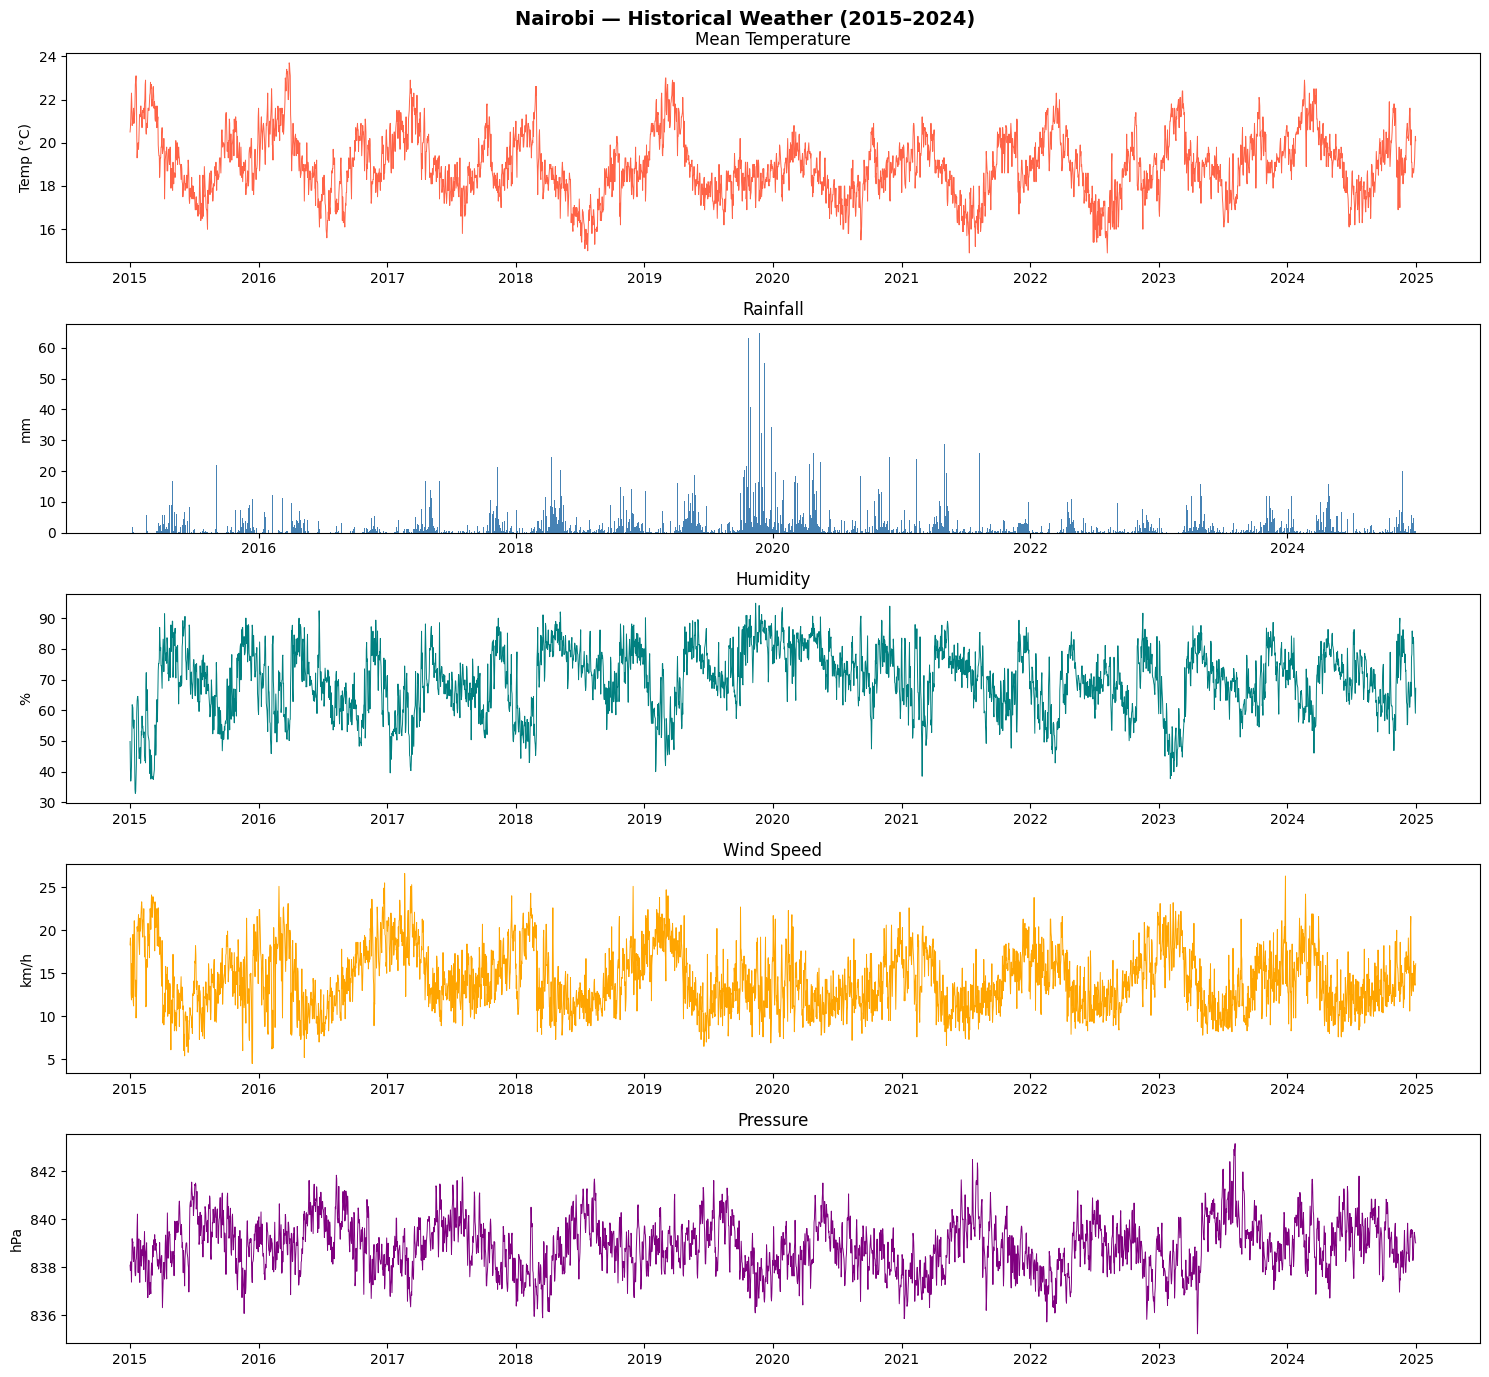

✅ EDA plot saved


In [ ]:
# Plot sample county to understand the data
sample = df[df['county'] == 'Nairobi'].copy()

fig, axes = plt.subplots(5, 1, figsize=(15, 14))
fig.suptitle('Nairobi — Historical Weather (2015–2024)', fontsize=14, fontweight='bold')

axes[0].plot(sample['date'], sample['temp_mean_c'], color='tomato', linewidth=0.7)
axes[0].set_ylabel('Temp (°C)'); axes[0].set_title('Mean Temperature')

axes[1].bar(sample['date'], sample['rainfall_mm'], color='steelblue', width=1)
axes[1].set_ylabel('mm'); axes[1].set_title('Rainfall')

axes[2].plot(sample['date'], sample['humidity_pct'], color='teal', linewidth=0.7)
axes[2].set_ylabel('%'); axes[2].set_title('Humidity')

axes[3].plot(sample['date'], sample['windspeed_kmh'], color='orange', linewidth=0.7)
axes[3].set_ylabel('km/h'); axes[3].set_title('Wind Speed')

axes[4].plot(sample['date'], sample['pressure_hpa'], color='purple', linewidth=0.7)
axes[4].set_ylabel('hPa'); axes[4].set_title('Pressure')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/nairobi_eda.png', dpi=150)
plt.show()
print('✅ EDA plot saved')

## 🛠️ Preprocessing & Feature Engineering

In [ ]:
# Target variables to predict
TARGET_COLS = ['temp_mean_c', 'rainfall_mm', 'humidity_pct', 'windspeed_kmh', 'pressure_hpa']

# ── Step 1: Handle missing values ────────────────────────────────────────────
df[TARGET_COLS] = df.groupby('county')[TARGET_COLS].transform(
    lambda x: x.interpolate(method='linear').fillna(method='bfill').fillna(method='ffill')
)
print(f'Missing after imputation: {df[TARGET_COLS].isnull().sum().sum()}')

# ── Step 2: Feature engineering ──────────────────────────────────────────────
df['day_of_year']  = df['date'].dt.dayofyear
df['month']        = df['date'].dt.month
df['week']         = df['date'].dt.isocalendar().week.astype(int)

# Cyclical encoding — captures seasonality properly
df['sin_doy'] = np.sin(2 * np.pi * df['day_of_year'] / 365)
df['cos_doy'] = np.cos(2 * np.pi * df['day_of_year'] / 365)
df['sin_month'] = np.sin(2 * np.pi * df['month'] / 12)
df['cos_month'] = np.cos(2 * np.pi * df['month'] / 12)

# Lag features (previous 1, 3, 7 days)
for col in TARGET_COLS:
    for lag in [1, 3, 7]:
        df[f'{col}_lag{lag}'] = df.groupby('county')[col].shift(lag)

# Rolling statistics (7-day and 14-day window)
for col in TARGET_COLS:
    for win in [7, 14]:
        df[f'{col}_roll{win}mean'] = df.groupby('county')[col].transform(
            lambda x: x.rolling(win, min_periods=1).mean()
        )

# Drop NaN rows created by lag features
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

print(f'✅ Feature engineering done')
print(f'   Final dataset: {df.shape[0]:,} rows × {df.shape[1]} columns')

Missing after imputation: 0
✅ Feature engineering done
   Final dataset: 171,362 rows × 45 columns


## 📊 Normalize & Build Sequences

In [ ]:
# Feature columns (everything except metadata)
EXCLUDE = ['date', 'county', 'latitude', 'longitude']
FEATURE_COLS = [c for c in df.columns if c not in EXCLUDE]

# Hyperparameters
LOOKBACK      = 30   # use past 30 days to predict
FORECAST_DAYS = 7    # predict next 7 days
N_TARGETS     = len(TARGET_COLS)

print(f'Feature columns  : {len(FEATURE_COLS)}')
print(f'Target columns   : {TARGET_COLS}')
print(f'Lookback window  : {LOOKBACK} days')
print(f'Forecast horizon : {FORECAST_DAYS} days')

# ── Normalize — fit scaler on training period only ───────────────────────────
# Chronological split: 70% train, 15% val, 15% test
counties    = df['county'].unique()
all_X, all_y = [], []

scaler_dict = {}   # one scaler per county for inverse transform later

for county in counties:
    cdf = df[df['county'] == county].copy().reset_index(drop=True)
    n   = len(cdf)

    # Fit scaler on training portion only (first 70%)
    train_end = int(n * 0.70)
    scaler    = MinMaxScaler()
    scaler.fit(cdf.iloc[:train_end][FEATURE_COLS])
    scaler_dict[county] = scaler

    scaled = scaler.transform(cdf[FEATURE_COLS])
    target_idx = [FEATURE_COLS.index(t) for t in TARGET_COLS]

    # Build sequences
    for i in range(LOOKBACK, n - FORECAST_DAYS):
        all_X.append(scaled[i - LOOKBACK : i])           # (30, n_features)
        all_y.append(scaled[i : i + FORECAST_DAYS, :][:, target_idx])  # (7, 5)

X = np.array(all_X, dtype=np.float32)   # (samples, 30, n_features)
y = np.array(all_y, dtype=np.float32)   # (samples, 7, 5)

print(f'\n✅ Sequences built')
print(f'   X shape: {X.shape}')
print(f'   y shape: {y.shape}')

# ── Chronological train/val/test split ───────────────────────────────────────
n_samples = len(X)
train_end = int(n_samples * 0.70)
val_end   = int(n_samples * 0.85)

X_train, y_train = X[:train_end],    y[:train_end]
X_val,   y_val   = X[train_end:val_end], y[train_end:val_end]
X_test,  y_test  = X[val_end:],      y[val_end:]

print(f'\n   Train : {X_train.shape[0]:,} samples')
print(f'   Val   : {X_val.shape[0]:,} samples')
print(f'   Test  : {X_test.shape[0]:,} samples')

# Save scalers for later use in deployment
joblib.dump(scaler_dict, f'{OUTPUT_DIR}/scalers.pkl')
joblib.dump(FEATURE_COLS, f'{OUTPUT_DIR}/feature_cols.pkl')
print('\n✅ Scalers saved')

Feature columns  : 41
Target columns   : ['temp_mean_c', 'rainfall_mm', 'humidity_pct', 'windspeed_kmh', 'pressure_hpa']
Lookback window  : 30 days
Forecast horizon : 7 days

✅ Sequences built
   X shape: (169623, 30, 41)
   y shape: (169623, 7, 5)

   Train : 118,736 samples
   Val   : 25,443 samples
   Test  : 25,444 samples

✅ Scalers saved


## 🧠 Common Callbacks & Eval Function

In [ ]:
def get_callbacks(model_name):
    return [
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
        ModelCheckpoint(f'{OUTPUT_DIR}/{model_name}_best.h5',
                        monitor='val_loss', save_best_only=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5,
                          min_lr=1e-6, verbose=1)
    ]


def evaluate_model(model, X_test, y_test, model_name):
    """Evaluate model and return metrics dict."""
    y_pred = model.predict(X_test, verbose=0)

    # Flatten for metric computation
    y_true_flat = y_test.reshape(-1, N_TARGETS)
    y_pred_flat = y_pred.reshape(-1, N_TARGETS)

    results = {'Model': model_name}
    for i, var in enumerate(TARGET_COLS):
        mae  = mean_absolute_error(y_true_flat[:, i], y_pred_flat[:, i])
        rmse = np.sqrt(mean_squared_error(y_true_flat[:, i], y_pred_flat[:, i]))
        r2   = r2_score(y_true_flat[:, i], y_pred_flat[:, i])
        mape_mask = y_true_flat[:, i] != 0
        mape = np.mean(np.abs((y_true_flat[mape_mask, i] - y_pred_flat[mape_mask, i])
                               / y_true_flat[mape_mask, i])) * 100 if mape_mask.sum() > 0 else np.nan
        results[f'{var}_MAE']  = round(mae, 4)
        results[f'{var}_RMSE'] = round(rmse, 4)
        results[f'{var}_R2']   = round(r2, 4)
        results[f'{var}_MAPE'] = round(mape, 2)

    # Overall mean metrics
    results['Overall_MAE']  = round(mean_absolute_error(y_true_flat, y_pred_flat), 4)
    results['Overall_RMSE'] = round(np.sqrt(mean_squared_error(y_true_flat, y_pred_flat)), 4)
    results['Overall_R2']   = round(r2_score(y_true_flat, y_pred_flat), 4)

    return results, y_pred

def plot_training(history, model_name):
    plt.figure(figsize=(10, 4))
    plt.plot(history.history['loss'],     label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f'{model_name} — Training History')
    plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
    plt.legend(); plt.grid(True, alpha=0.3)
    plt.savefig(f'{OUTPUT_DIR}/{model_name}_training.png', dpi=150)
    plt.show()

all_results = []   # collect results from all models
all_preds   = {}   # store predictions
print('✅ Helper functions ready')

✅ Helper functions ready


## 🔵 Model 1: LSTM

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 30, 41)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 30, 128)        │        87,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 35)             │         2,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 5)           │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 143,395 (560.14 KB)

 Trainable params: 143,139 (559.14 KB)

 Non-trainable params: 256 (1.00 KB)

...

1856/1856 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - loss: 0.0068 - mae: 0.0602 - val_loss: 0.0080 - val_mae: 0.0656 - learning_rate: 0.0010
Epoch 29/100
1856/1856 ━━━━━━━━━━━━━━━━━━━━ 41s 11ms/step - loss: 0.0067 - mae: 0.0600 - val_loss: 0.0082 - val_mae: 0.0664 - learning_rate: 0.0010
Epoch 30/100
1855/1856 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0067 - mae: 0.0598

1856/1856 ━━━━━━━━━━━━━━━━━━━━ 42s 12ms/step - loss: 0.0067 - mae: 0.0598 - val_loss: 0.0080 - val_mae: 0.0652 - learning_rate: 0.0010
Epoch 31/100
1856/1856 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - loss: 0.0066 - mae: 0.0595 - val_loss: 0.0080 - val_mae: 0.0655 - learning_rate: 0.0010
Epoch 32/100
1854/1856 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0066 - mae: 0.0593

1856/1856 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - loss: 0.0066 - mae: 0.0593 - val_loss: 0.0079 - val_mae: 0.0651 - learning_rate: 0.0010
Epoch 33/100
1856/1856 ━━━━━━━━━━━━━━━━━━━━ 40s 11ms/step - loss: 0.0065 - mae: 0.0590 - val_loss: 0.0080 - val_mae: 0.0654 - learning_rate: 0.0010
Epoch 34/100
1856/1856 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - loss: 0.0065 - mae: 0.0588 - val_loss: 0.0080 - val_mae: 0.0653 - learning_rate: 0.0010
Epoch 35/100
1856/1856 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - loss: 0.0064 - mae: 0.0586 - val_loss: 0.0080 - val_mae: 0.0655 - learning_rate: 0.0010
Epoch 36/100
1856/1856 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - loss: 0.0064 - mae: 0.0584 - val_loss: 0.0080 - val_mae: 0.0655 - learning_rate: 0.0010
Epoch 37/100
1854/1856 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0064 - mae: 0.0583


Epoch 37: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1856/1856 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - loss: 0.0064 - mae: 0.0583 - val_loss: 0.0079 - val_mae: 0.0650 - learning_rate: 0.0010
Epoch 38/100
1856/1856 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - loss: 0.0061 - mae: 0.0572 - val_loss: 0.0081 - val_mae: 0.0658 - learning_rate: 5.0000e-04
Epoch 39/100
1856/1856 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - loss: 0.0061 - mae: 0.0568 - val_loss: 0.0080 - val_mae: 0.0653 - learning_rate: 5.0000e-04
Epoch 40/100
1856/1856 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - loss: 0.0060 - mae: 0.0567 - val_loss: 0.0080 - val_mae: 0.0657 - learning_rate: 5.0000e-04
Epoch 41/100
1856/1856 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - loss: 0.0060 - mae: 0.0565 - val_loss: 0.0080 - val_mae: 0.0655 - learning_rate: 5.0000e-04
Epoch 42/100
1851/1856 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0060 - mae: 0.0565
Epoch 42: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
1856/1856 ━━━━━━

1856/1856 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - loss: 0.0059 - mae: 0.0559 - val_loss: 0.0078 - val_mae: 0.0646 - learning_rate: 2.5000e-04
Epoch 44/100
1856/1856 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - loss: 0.0059 - mae: 0.0557 - val_loss: 0.0078 - val_mae: 0.0647 - learning_rate: 2.5000e-04
Epoch 45/100
1856/1856 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - loss: 0.0058 - mae: 0.0556 - val_loss: 0.0079 - val_mae: 0.0651 - learning_rate: 2.5000e-04
Epoch 46/100
1856/1856 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - loss: 0.0058 - mae: 0.0556 - val_loss: 0.0079 - val_mae: 0.0650 - learning_rate: 2.5000e-04
Epoch 47/100
1856/1856 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - loss: 0.0058 - mae: 0.0555 - val_loss: 0.0079 - val_mae: 0.0648 - learning_rate: 2.5000e-04
Epoch 48/100
1854/1856 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0058 - mae: 0.0554
Epoch 48: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
1856/1856 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - loss: 0.0058 - mae: 0.0554 - val_loss: 0.00

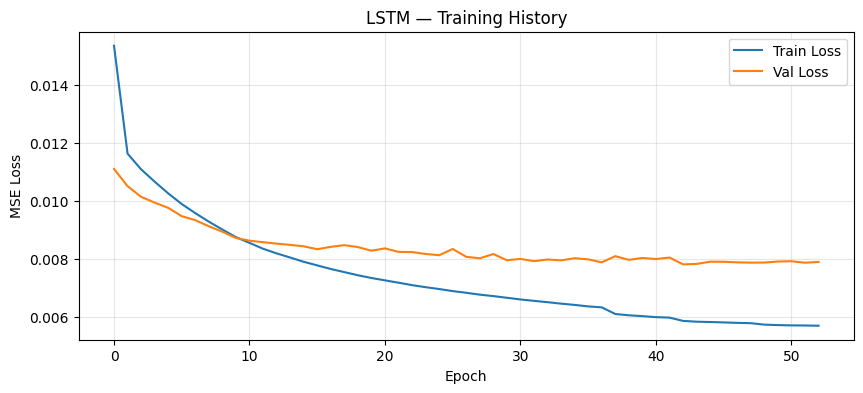


✅ LSTM Results:
   Overall MAE  : 0.0716
   Overall RMSE : 0.098
   Overall R²   : 0.6018


In [ ]:
N_FEATURES = X_train.shape[2]

def build_lstm():
    inp = Input(shape=(LOOKBACK, N_FEATURES))
    x   = LSTM(128, return_sequences=True)(inp)
    x   = Dropout(0.2)(x)
    x   = BatchNormalization()(x)
    x   = LSTM(64, return_sequences=False)(x)
    x   = Dropout(0.2)(x)
    x   = Dense(64, activation='relu')(x)
    out = Dense(FORECAST_DAYS * N_TARGETS)(x)
    out = Reshape((FORECAST_DAYS, N_TARGETS))(out)
    model = Model(inp, out)
    model.compile(optimizer=Adam(learning_rate=1e-3), loss='mse', metrics=['mae'])
    return model

lstm_model = build_lstm()
lstm_model.summary()

print('\n🏋️ Training LSTM...')
lstm_history = lstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=64,
    callbacks=get_callbacks('LSTM'),
    verbose=1
)

plot_training(lstm_history, 'LSTM')

lstm_results, lstm_preds = evaluate_model(lstm_model, X_test, y_test, 'LSTM')
all_results.append(lstm_results)
all_preds['LSTM'] = lstm_preds

print('\n✅ LSTM Results:')
print(f"   Overall MAE  : {lstm_results['Overall_MAE']}")
print(f"   Overall RMSE : {lstm_results['Overall_RMSE']}")
print(f"   Overall R²   : {lstm_results['Overall_R2']}")

## 🟢  Model 2: GRU

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 30, 41)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 30, 128)        │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 30, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 35)             │         2,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 7, 5)           │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,859 (429.14 KB)

 Trainable params: 109,603 (428.14 KB)

 Non-trainable params: 256 (1.00 KB)

...

1856/1856 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - loss: 0.0057 - mae: 0.0551 - val_loss: 0.0066 - val_mae: 0.0584 - learning_rate: 1.2500e-04
Epoch 47/100
1856/1856 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - loss: 0.0057 - mae: 0.0551 - val_loss: 0.0066 - val_mae: 0.0584 - learning_rate: 1.2500e-04
Epoch 48/100
1852/1856 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0057 - mae: 0.0550

1856/1856 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - loss: 0.0057 - mae: 0.0550 - val_loss: 0.0066 - val_mae: 0.0584 - learning_rate: 1.2500e-04
Epoch 49/100
1853/1856 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0057 - mae: 0.0550
Epoch 49: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.
1856/1856 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - loss: 0.0057 - mae: 0.0550 - val_loss: 0.0066 - val_mae: 0.0584 - learning_rate: 1.2500e-04
Epoch 50/100
1855/1856 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0057 - mae: 0.0548

1856/1856 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - loss: 0.0057 - mae: 0.0548 - val_loss: 0.0066 - val_mae: 0.0583 - learning_rate: 6.2500e-05
Epoch 51/100
1856/1856 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - loss: 0.0057 - mae: 0.0548 - val_loss: 0.0066 - val_mae: 0.0583 - learning_rate: 6.2500e-05
Epoch 52/100
1856/1856 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - loss: 0.0057 - mae: 0.0548 - val_loss: 0.0066 - val_mae: 0.0583 - learning_rate: 6.2500e-05
Epoch 53/100
1856/1856 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step - loss: 0.0057 - mae: 0.0548 - val_loss: 0.0066 - val_mae: 0.0583 - learning_rate: 6.2500e-05
Epoch 54/100
1854/1856 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0057 - mae: 0.0548
Epoch 54: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.
1856/1856 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - loss: 0.0057 - mae: 0.0548 - val_loss: 0.0066 - val_mae: 0.0583 - learning_rate: 6.2500e-05
Epoch 55/100
1856/1856 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - loss: 0.0056 - mae: 0.0546 - val_loss: 0.006

1856/1856 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - loss: 0.0056 - mae: 0.0546 - val_loss: 0.0066 - val_mae: 0.0583 - learning_rate: 3.1250e-05
Epoch 57/100
1851/1856 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0056 - mae: 0.0546

1856/1856 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - loss: 0.0056 - mae: 0.0546 - val_loss: 0.0066 - val_mae: 0.0583 - learning_rate: 3.1250e-05
Epoch 58/100
1856/1856 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - loss: 0.0056 - mae: 0.0546 - val_loss: 0.0066 - val_mae: 0.0583 - learning_rate: 3.1250e-05
Epoch 59/100
1855/1856 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0056 - mae: 0.0546
Epoch 59: ReduceLROnPlateau reducing learning rate to 1.5625000742147677e-05.
1856/1856 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - loss: 0.0056 - mae: 0.0546 - val_loss: 0.0066 - val_mae: 0.0583 - learning_rate: 3.1250e-05
Epoch 60/100
1856/1856 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - loss: 0.0056 - mae: 0.0545 - val_loss: 0.0066 - val_mae: 0.0583 - learning_rate: 1.5625e-05
Epoch 61/100
1856/1856 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - loss: 0.0056 - mae: 0.0546 - val_loss: 0.0066 - val_mae: 0.0583 - learning_rate: 1.5625e-05
Epoch 62/100
1856/1856 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - loss: 0.0056 - mae: 0.0545 - val_loss: 0.00

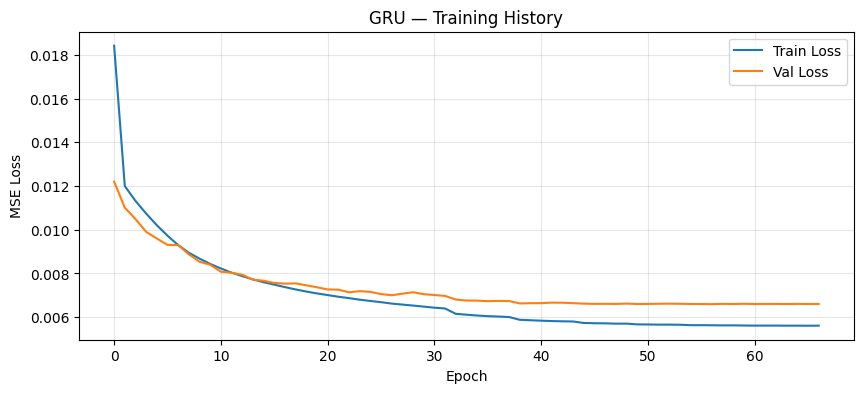


✅ GRU Results:
   Overall MAE  : 0.0635
   Overall RMSE : 0.0896
   Overall R²   : 0.6511


In [ ]:
def build_gru():
    inp = Input(shape=(LOOKBACK, N_FEATURES))
    x   = GRU(128, return_sequences=True)(inp)
    x   = Dropout(0.2)(x)
    x   = BatchNormalization()(x)
    x   = GRU(64, return_sequences=False)(x)
    x   = Dropout(0.2)(x)
    x   = Dense(64, activation='relu')(x)
    out = Dense(FORECAST_DAYS * N_TARGETS)(x)
    out = Reshape((FORECAST_DAYS, N_TARGETS))(out)
    model = Model(inp, out)
    model.compile(optimizer=Adam(learning_rate=1e-3), loss='mse', metrics=['mae'])
    return model

gru_model = build_gru()
gru_model.summary()

print('\n🏋️ Training GRU...')
gru_history = gru_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=64,
    callbacks=get_callbacks('GRU'),
    verbose=1
)

plot_training(gru_history, 'GRU')

gru_results, gru_preds = evaluate_model(gru_model, X_test, y_test, 'GRU')
all_results.append(gru_results)
all_preds['GRU'] = gru_preds

print('\n✅ GRU Results:')
print(f"   Overall MAE  : {gru_results['Overall_MAE']}")
print(f"   Overall RMSE : {gru_results['Overall_RMSE']}")
print(f"   Overall R²   : {gru_results['Overall_R2']}")

## 🟠 Model 3: ConvLSTM

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 6, 1, 5, 41)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_lstm2d_2 (ConvLSTM2D)      │ (None, 6, 1, 5, 32)    │        28,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 6, 1, 5, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_lstm2d_3 (ConvLSTM2D)      │ (None, 1, 5, 16)       │         9,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 80)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         5,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 35)             │         2,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_3 (Reshape)             │ (None, 7, 5)           │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,899 (175.39 KB)

 Trainable params: 44,899 (175.39 KB)

 Non-trainable params: 0 (0.00 B)

...

1856/1856 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - loss: 0.0093 - mae: 0.0710 - val_loss: 0.0089 - val_mae: 0.0692 - learning_rate: 6.2500e-05
Epoch 48/100
1850/1856 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0093 - mae: 0.0710

1856/1856 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 0.0093 - mae: 0.0710 - val_loss: 0.0089 - val_mae: 0.0692 - learning_rate: 6.2500e-05
Epoch 49/100
1856/1856 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 0.0093 - mae: 0.0710 - val_loss: 0.0089 - val_mae: 0.0692 - learning_rate: 6.2500e-05
Epoch 50/100
1854/1856 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0093 - mae: 0.0710

1856/1856 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - loss: 0.0093 - mae: 0.0710 - val_loss: 0.0089 - val_mae: 0.0692 - learning_rate: 6.2500e-05
Epoch 51/100
1856/1856 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 0.0093 - mae: 0.0710 - val_loss: 0.0089 - val_mae: 0.0692 - learning_rate: 6.2500e-05
Epoch 52/100
1854/1856 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0093 - mae: 0.0711
Epoch 52: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.
1856/1856 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 0.0093 - mae: 0.0711 - val_loss: 0.0089 - val_mae: 0.0692 - learning_rate: 6.2500e-05
Epoch 53/100
1856/1856 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 0.0093 - mae: 0.0709 - val_loss: 0.0089 - val_mae: 0.0692 - learning_rate: 3.1250e-05
Epoch 54/100
1856/1856 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 0.0093 - mae: 0.0710 - val_loss: 0.0089 - val_mae: 0.0692 - learning_rate: 3.1250e-05
Epoch 55/100
1856/1856 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 0.0093 - mae: 0.0709 - val_loss: 0.0089 - v

1856/1856 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 0.0093 - mae: 0.0709 - val_loss: 0.0089 - val_mae: 0.0691 - learning_rate: 3.1250e-05
Epoch 57/100
1854/1856 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0093 - mae: 0.0709
Epoch 57: ReduceLROnPlateau reducing learning rate to 1.5625000742147677e-05.
1856/1856 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 0.0093 - mae: 0.0709 - val_loss: 0.0089 - val_mae: 0.0691 - learning_rate: 3.1250e-05
Epoch 58/100
1856/1856 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 0.0093 - mae: 0.0709 - val_loss: 0.0089 - val_mae: 0.0692 - learning_rate: 1.5625e-05
Epoch 59/100
1856/1856 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 0.0093 - mae: 0.0709 - val_loss: 0.0089 - val_mae: 0.0691 - learning_rate: 1.5625e-05
Epoch 60/100
1856/1856 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 0.0093 - mae: 0.0709 - val_loss: 0.0089 - val_mae: 0.0691 - learning_rate: 1.5625e-05
Epoch 61/100
1856/1856 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 0.0093 - mae: 0.0709 - val_loss: 0.0089 - v

1856/1856 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - loss: 0.0092 - mae: 0.0709 - val_loss: 0.0089 - val_mae: 0.0691 - learning_rate: 7.8125e-06
Epoch 67/100
1855/1856 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0092 - mae: 0.0709
Epoch 67: ReduceLROnPlateau reducing learning rate to 3.906250185536919e-06.
1856/1856 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 0.0092 - mae: 0.0709 - val_loss: 0.0089 - val_mae: 0.0691 - learning_rate: 7.8125e-06
Epoch 68/100
1856/1856 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 0.0092 - mae: 0.0709 - val_loss: 0.0089 - val_mae: 0.0691 - learning_rate: 3.9063e-06
Epoch 69/100
1856/1856 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - loss: 0.0092 - mae: 0.0709 - val_loss: 0.0089 - val_mae: 0.0691 - learning_rate: 3.9063e-06
Epoch 70/100
1856/1856 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 0.0093 - mae: 0.0709 - val_loss: 0.0089 - val_mae: 0.0691 - learning_rate: 3.9063e-06
Epoch 71/100
1856/1856 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 0.0092 - mae: 0.0708 - val_loss: 0.0089 - v

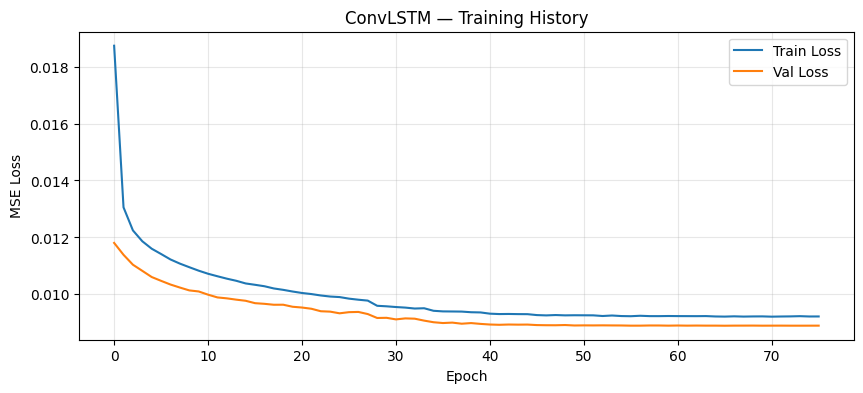


✅ ConvLSTM Results:
   Overall MAE  : 0.0725
   Overall RMSE : 0.0996
   Overall R²   : 0.58


In [ ]:
# ConvLSTM expects 5D input: (samples, time_steps, rows, cols, features)
# We reshape our 30-day sequence into 6 time blocks of 5 days each
TIME_BLOCKS = 6
DAYS_PER_BLOCK = 5   # 6 * 5 = 30 days

def reshape_for_convlstm(X):
    # X: (samples, 30, n_features) → (samples, 6, 1, 5, n_features)
    return X.reshape(X.shape[0], TIME_BLOCKS, 1, DAYS_PER_BLOCK, N_FEATURES)

X_train_c = reshape_for_convlstm(X_train)
X_val_c   = reshape_for_convlstm(X_val)
X_test_c  = reshape_for_convlstm(X_test)

def build_convlstm():
    inp = Input(shape=(TIME_BLOCKS, 1, DAYS_PER_BLOCK, N_FEATURES))
    x   = ConvLSTM2D(filters=32, kernel_size=(1, 3), padding='same',
                     return_sequences=True, activation='relu')(inp)
    x   = Dropout(0.2)(x)
    x   = ConvLSTM2D(filters=16, kernel_size=(1, 3), padding='same',
                     return_sequences=False, activation='relu')(x)
    x   = Flatten()(x)
    x   = Dense(64, activation='relu')(x)
    x   = Dropout(0.2)(x)
    out = Dense(FORECAST_DAYS * N_TARGETS)(x)
    out = Reshape((FORECAST_DAYS, N_TARGETS))(out)
    model = Model(inp, out)
    model.compile(optimizer=Adam(learning_rate=1e-3), loss='mse', metrics=['mae'])
    return model

convlstm_model = build_convlstm()
convlstm_model.summary()

print('\n🏋️ Training ConvLSTM...')
convlstm_history = convlstm_model.fit(
    X_train_c, y_train,
    validation_data=(X_val_c, y_val),
    epochs=100,
    batch_size=64,
    callbacks=get_callbacks('ConvLSTM'),
    verbose=1
)

plot_training(convlstm_history, 'ConvLSTM')

convlstm_results, convlstm_preds = evaluate_model(convlstm_model, X_test_c, y_test, 'ConvLSTM')
all_results.append(convlstm_results)
all_preds['ConvLSTM'] = convlstm_preds

print('\n✅ ConvLSTM Results:')
print(f"   Overall MAE  : {convlstm_results['Overall_MAE']}")
print(f"   Overall RMSE : {convlstm_results['Overall_RMSE']}")
print(f"   Overall R²   : {convlstm_results['Overall_R2']}")

## 📊 Model Comparison

In [ ]:
results_df = pd.DataFrame(all_results)

# Show key comparison table
summary_cols = ['Model', 'Overall_MAE', 'Overall_RMSE', 'Overall_R2'] + \
               [f'{v}_MAE' for v in TARGET_COLS]
print('=' * 70)
print('MODEL COMPARISON SUMMARY')
print('=' * 70)
print(results_df[summary_cols].to_string(index=False))

# Save full results
results_df.to_csv(f'{OUTPUT_DIR}/model_comparison.csv', index=False)
print(f'\n✅ Full results saved to model_comparison.csv')

# Identify best model
best_idx   = results_df['Overall_RMSE'].idxmin()
best_model = results_df.loc[best_idx, 'Model']
print(f'\n🏆 Best Model: {best_model}')
print(f"   MAE  : {results_df.loc[best_idx, 'Overall_MAE']}")
print(f"   RMSE : {results_df.loc[best_idx, 'Overall_RMSE']}")
print(f"   R²   : {results_df.loc[best_idx, 'Overall_R2']}")

MODEL COMPARISON SUMMARY
   Model  Overall_MAE  Overall_RMSE  Overall_R2  temp_mean_c_MAE  rainfall_mm_MAE  humidity_pct_MAE  windspeed_kmh_MAE  pressure_hpa_MAE
    LSTM       0.0716        0.0980      0.6018           0.0738           0.0390            0.0859             0.0936            0.0655
     GRU       0.0635        0.0896      0.6511           0.0612           0.0360            0.0703             0.0914            0.0587
ConvLSTM       0.0745        0.1019      0.5635           0.0707           0.0413            0.0849             0.0957            0.0800
ConvLSTM       0.0725        0.0996      0.5800           0.0686           0.0400            0.0822             0.0944            0.0771

✅ Full results saved to model_comparison.csv

🏆 Best Model: GRU
   MAE  : 0.0635
   RMSE : 0.0896
   R²   : 0.6511


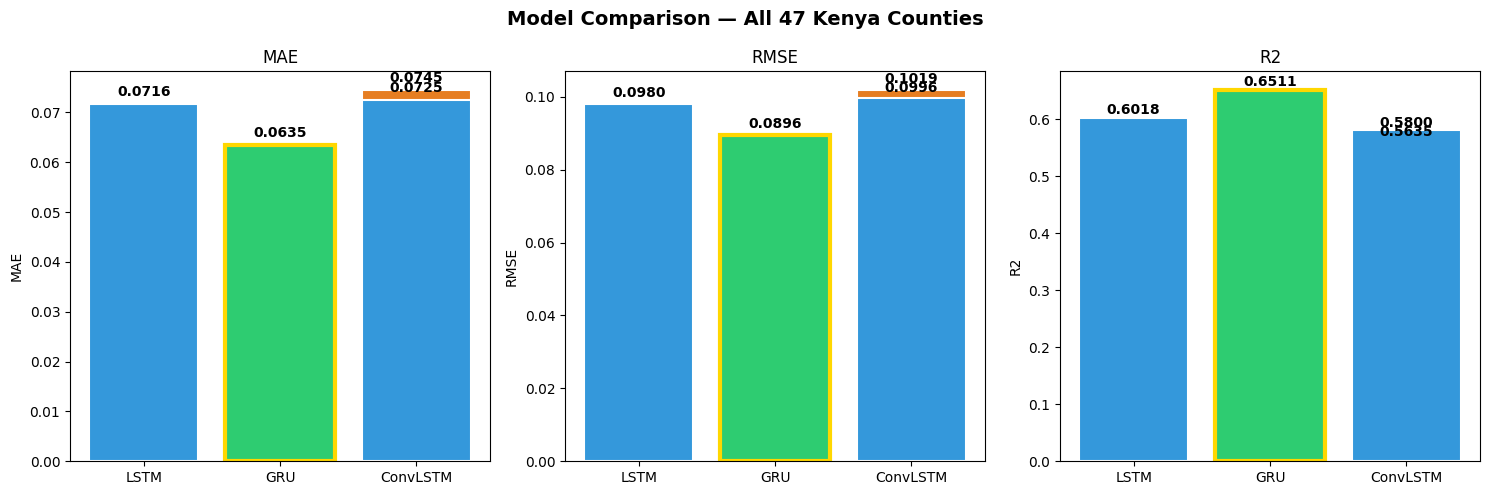

✅ Comparison chart saved


In [ ]:
# Visual comparison bar chart
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Model Comparison — All 47 Kenya Counties', fontsize=14, fontweight='bold')

colors = ['#3498db', '#2ecc71', '#e67e22']
models = results_df['Model'].tolist()

for ax, metric in zip(axes, ['Overall_MAE', 'Overall_RMSE', 'Overall_R2']):
    vals = results_df[metric].tolist()
    bars = ax.bar(models, vals, color=colors, edgecolor='white', linewidth=1.5)
    ax.set_title(metric.replace('Overall_', ''))
    ax.set_ylabel(metric.replace('Overall_', ''))
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    # Highlight best
    best_i = vals.index(min(vals)) if 'R2' not in metric else vals.index(max(vals))
    bars[best_i].set_edgecolor('gold')
    bars[best_i].set_linewidth(3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/model_comparison.png', dpi=150)
plt.show()
print('✅ Comparison chart saved')

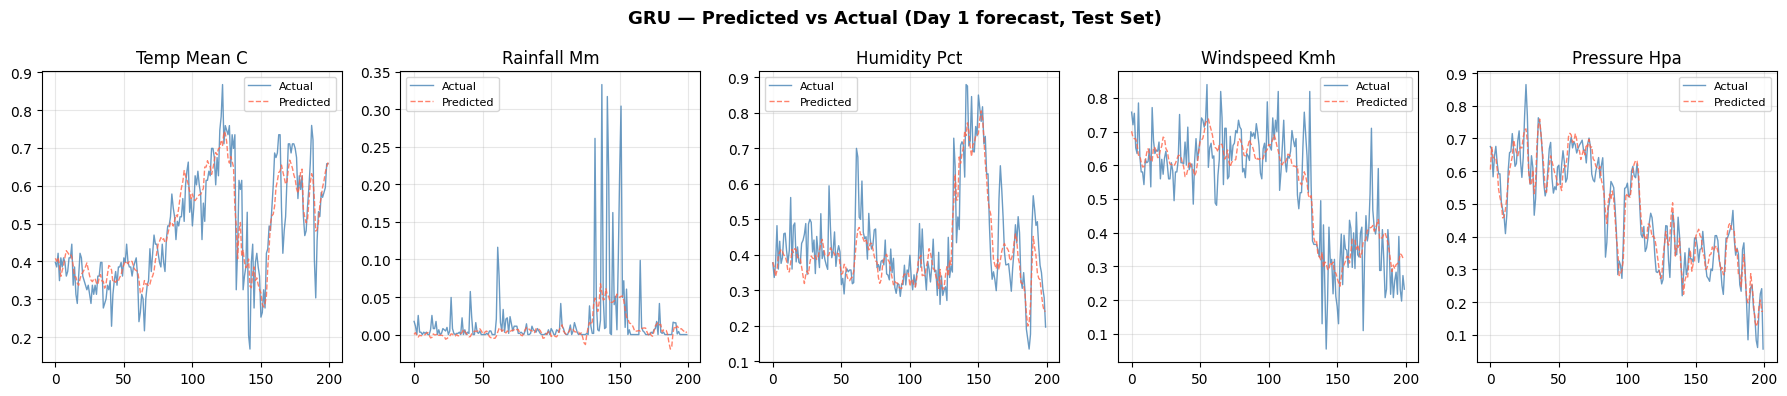

✅ Prediction plot saved


In [ ]:
# Predicted vs Actual plot for best model
best_preds = all_preds[best_model]
fig, axes  = plt.subplots(1, len(TARGET_COLS), figsize=(18, 4))
fig.suptitle(f'{best_model} — Predicted vs Actual (Day 1 forecast, Test Set)', fontsize=13, fontweight='bold')

for i, (ax, var) in enumerate(zip(axes, TARGET_COLS)):
    actual = y_test[:200, 0, i]       # first 200 samples, day 1
    pred   = best_preds[:200, 0, i]
    ax.plot(actual, label='Actual',    color='steelblue', linewidth=1, alpha=0.8)
    ax.plot(pred,   label='Predicted', color='tomato',    linewidth=1, alpha=0.8, linestyle='--')
    ax.set_title(var.replace('_', ' ').title())
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/predicted_vs_actual.png', dpi=150)
plt.show()
print('✅ Prediction plot saved')

## 💾  Save Best Model & Metadata

In [ ]:
# Save the best model
best_model_obj = {'LSTM': lstm_model, 'GRU': gru_model, 'ConvLSTM': convlstm_model}[best_model]
best_model_obj.save(f'{OUTPUT_DIR}/best_model_{best_model}.h5')

# Save metadata needed for deployment
import json
metadata = {
    'best_model'    : best_model,
    'lookback'      : LOOKBACK,
    'forecast_days' : FORECAST_DAYS,
    'target_cols'   : TARGET_COLS,
    'feature_cols'  : FEATURE_COLS,
    'n_features'    : N_FEATURES,
    'n_targets'     : N_TARGETS,
    'counties'      : list(counties),
    'results'       : results_df[['Model','Overall_MAE','Overall_RMSE','Overall_R2']].to_dict('records')
}

with open(f'{OUTPUT_DIR}/model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print('=' * 50)
print('✅ ALL FILES SAVED TO GOOGLE DRIVE:')
print(f'   📁 {OUTPUT_DIR}/')
for f in os.listdir(OUTPUT_DIR):
    size = os.path.getsize(f'{OUTPUT_DIR}/{f}') / 1024
    print(f'   └─ {f:40s} {size:8.1f} KB')
print('=' * 50)
print(f'\n🏆 Best model: {best_model}')
print('\n👉 Next step: Use the map visualization notebook to deploy!')

✅ ALL FILES SAVED TO GOOGLE DRIVE:
   📁 /content/drive/MyDrive/kenya_models/
   └─ nairobi_eda.png                             624.8 KB
   └─ scalers.pkl                                 134.8 KB
   └─ feature_cols.pkl                              0.8 KB
   └─ LSTM_best.h5                               1727.7 KB
   └─ LSTM_training.png                            52.5 KB
   └─ GRU_best.h5                                1335.9 KB
   └─ GRU_training.png                             51.4 KB
   └─ ConvLSTM_best.h5                            572.9 KB
   └─ ConvLSTM_training.png                        49.0 KB
   └─ model_comparison.csv                          1.0 KB
   └─ model_comparison.png                         73.4 KB
   └─ predicted_vs_actual.png                     292.7 KB
   └─ best_model_GRU.h5                          1335.9 KB
   └─ model_metadata.json                           2.4 KB

🏆 Best model: GRU

👉 Next step: Use the map visualization notebook to deploy!
